In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [3]:
#this line forces it to show all the columns instead of only the first and last columns
pd.set_option('display.max_columns', None)

In [4]:
#reading in Eugene emergency response data 2015-2025

CAD2015 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2015noloc.csv",na_values='NULL')
CAD2016 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2016noloc.csv",na_values='NULL')
CAD2017 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2017noloc.csv",na_values='NULL')
CAD2018 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2018noloc.csv",na_values='NULL')
CAD2019 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2019noloc.csv",na_values='NULL')
CAD2020 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2020noloc.csv",na_values='NULL')
CAD2021 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2021noloc.csv",na_values='NULL')
CAD2022 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2022noloc.csv",na_values='NULL')
CAD2023 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2023noloc.csv",na_values='NULL')
CAD2024 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2024noloc.csv",na_values='NULL')
CAD2025 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2025noloc.csv",na_values='NULL')

/var/folders/0y/gklqyv_101130y1ly46wc5wm0000gn/T/ipykernel_3635/2484449190.py:9: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  CAD2021 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2021noloc.csv",na_values='NULL')
/var/folders/0y/gklqyv_101130y1ly46wc5wm0000gn/T/ipykernel_3635/2484449190.py:13: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  CAD2025 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2025noloc.csv",na_values='NULL')


In [5]:
#example
CAD2015.head()

,yr,agency,service,inci_id,calltime,case_id,callsource,nature,closecode,closed_as,secs_to_disp,secs_to_arrv,secs_to_close,disp,arrv,priority,primeunit,units_dispd,units_arrived
0,2015,EPD,LAW,15000001,2015-01-01 00:00:00.000,NaN,SELF,PERSON STOP,ASST,ASSISTED,0.0,0.0,217,1,1,6,_5E48,1,1
1,2015,EPD,LAW,15000002,2015-01-01 00:00:44.000,NaN,SELF,FIGHT,RSLV,RESOLVED,0.0,0.0,2114,1,1,P,_3F65,4,2
2,2015,EPD,LAW,15000003,2015-01-01 00:01:05.000,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,708.0,1094.0,1538,1,1,5,_3J79,1,1
3,2015,EPD,LAW,15000007,2015-01-01 00:03:16.000,NaN,W911,SHOTS FIRED,PCHK,PATROL CHECK,277.0,576.0,891,1,1,3,_5E48,2,2
4,2015,EPD,LAW,15000010,2015-01-01 00:03:34.000,NaN,SELF,ILLEGAL FIREWORKS,ADVI,ADVISED,0.0,0.0,150,1,1,5,_5K97,1,1


In [6]:
#making sure that welfare checks are only coded one way in each data set:
#CAD2015['nature'].unique() #'CHECK WELFARE'
#CAD2016['nature'].unique() #'CHECK WELFARE'
#CAD2017['nature'].unique() #'CHECK WELFARE'
#CAD2018['nature'].unique() #'CHECK WELFARE'
#CAD2019['nature'].unique() #'CHECK WELFARE'
#CAD2020['nature'].unique() #'CHECK WELFARE'
#CAD2021['nature'].unique() #'CHECK WELFARE'
#CAD2025['nature'].unique() #'CHECK WELFARE'
#Yes. There's nothing else similar that's in that category (and no typos).
#So I can filter by a call nature of CHECK WELFARE

In [7]:
#Note: other types of calls sometimes ended in a welfare check. 
#Did missing person reports or similar?
CAD2015[CAD2015['nature'] == 'MISSING PERSON']['closed_as'].unique() #no
CAD2015[CAD2015['nature'] == 'LOCATION WANTED SUBJECT']['closed_as'].unique() #no
CAD2015[CAD2015['nature'] == 'LOCATE MISSING PERSON']['closed_as'].unique() #no
CAD2015[CAD2015['nature'] == 'CITIZEN CONTACT']['closed_as'].unique() #no
CAD2015[CAD2015['nature'] == 'OVERDUE SUBJECT']['closed_as'].unique() #no
CAD2015[CAD2015['nature'] == 'REQUEST ASSISTANCE']['closed_as'].unique() #no
CAD2015[CAD2015['nature'] == 'VACATION CHECK']['closed_as'].unique() #no
CAD2015[CAD2015['nature'] == 'ILL SUBJECT']['closed_as'].unique() #no
CAD2015[CAD2015['nature'] == 'COMMUNITY POLICING ACTIVITY']['closed_as'].unique() #no

CAD2018[CAD2018['nature'] == 'EMERGENCY LOCATE REQUEST']['closed_as'].unique() #no

array(['REFERRED TO OTHER AGENCY', 'PUBLIC WORKS'], dtype=object)

In [45]:
#filtering each of the data sets to only include welfare check calls (requests for a welfare check)
WELFARE2015 = CAD2015[(CAD2015['nature'] == 'CHECK WELFARE') | (CAD2015['nature'] == 'CHECK WELFARE, CAHOOTS')]
WELFARE2016 = CAD2016[(CAD2016['nature'] == 'CHECK WELFARE') | (CAD2016['nature'] == 'CHECK WELFARE, CAHOOTS')]
WELFARE2017 = CAD2017[(CAD2017['nature'] == 'CHECK WELFARE') | (CAD2017['nature'] == 'CHECK WELFARE, CAHOOTS')]
WELFARE2018 = CAD2018[(CAD2018['nature'] == 'CHECK WELFARE') | (CAD2018['nature'] == 'CHECK WELFARE, CAHOOTS')]
WELFARE2019 = CAD2019[(CAD2019['nature'] == 'CHECK WELFARE') | (CAD2019['nature'] == 'CHECK WELFARE, CAHOOTS')]
WELFARE2020 = CAD2020[(CAD2020['nature'] == 'CHECK WELFARE') | (CAD2020['nature'] == 'CHECK WELFARE, CAHOOTS')]
WELFARE2021 = CAD2021[(CAD2021['nature'] == 'CHECK WELFARE') | (CAD2021['nature'] == 'CHECK WELFARE, CAHOOTS')]
WELFARE2022 = CAD2022[(CAD2022['nature'] == 'CHECK WELFARE') | (CAD2022['nature'] == 'CHECK WELFARE, CAHOOTS')]
WELFARE2023 = CAD2023[(CAD2023['nature'] == 'CHECK WELFARE') | (CAD2023['nature'] == 'CHECK WELFARE, CAHOOTS')]
WELFARE2024 = CAD2024[(CAD2024['nature'] == 'CHECK WELFARE') | (CAD2024['nature'] == 'CHECK WELFARE, CAHOOTS')]
WELFARE2025 = CAD2025[(CAD2025['nature'] == 'CHECK WELFARE') | (CAD2025['nature'] == 'CHECK WELFARE, CAHOOTS')]

In [46]:
#putting all WELFARE data frames 2015-25 into a single data frame
frames = [WELFARE2015, WELFARE2016, WELFARE2017, WELFARE2018, WELFARE2019, WELFARE2020,
          WELFARE2021, WELFARE2022, WELFARE2023, WELFARE2024, WELFARE2025]

WELFARE = pd.concat(frames)
WELFARE

,yr,agency,service,inci_id,calltime,case_id,callsource,nature,closecode,closed_as,secs_to_disp,secs_to_arrv,secs_to_close,disp,arrv,priority,primeunit,units_dispd,units_arrived,month
2,2015,EPD,LAW,15000003,2015-01-01 00:01:05.000,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,708.0,1094.0,1538,1,1,5,_3J79,1,1,NaN
27,2015,EPD,LAW,15000052,2015-01-01 00:38:37.000,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,2402.0,2941.0,3594,1,1,5,_3J79,1,1,NaN
47,2015,EPD,LAW,15000092,2015-01-01 01:28:40.000,NaN,PHONE,CHECK WELFARE,UTL,UNABLE TO LOCATE,1305.0,1524.0,1824,1,1,5,_5B44,1,1,NaN
55,2015,EPD,LAW,15000107,2015-01-01 01:41:40.000,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,600.0,926.0,1285,1,1,5,_3J79,1,1,NaN
186,2015,EPD,LAW,15000435,2015-01-01 15:09:21.000,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,3018.0,3605.0,4369,1,1,7,_3J79,1,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117254,2025,EPD,LAW,25327100,2025-12-31 17:12:02.000,NaN,PHONE,CHECK WELFARE,DDIS,DISREGARDED BY DISPATCH,NaN,NaN,4147,0,0,4,NaN,0,0,12.0
117265,2025,EPD,LAW,25327137,2025-12-31 17:56:18.000,NaN,PHONE,CHECK WELFARE,UTL,UNABLE TO LOCATE,5655.0,6292.0,8294,1,1,3,_4U72,2,2,12.0
117284,2025,EPD,LAW,25327208,2025-12-31 20:23:13.000,NaN,PHONE,CHECK WELFARE,WELC,WELFARE CHECK DONE,2828.0,3001.0,3451,1,1,3,_5E56,2,2,12.0
117295,2025,EPD,LAW,25327228,2025-12-31 20:50:01.000,NaN,W911,CHECK WELFARE,DIS,DISREGARD,354.0,740.0,818,1,1,3,_4U72,2,2,12.0


In [47]:
#reset the index
WELFARE.reset_index(inplace=True)

In [48]:
#Strip whitespace and leading "_" from the primeunit column
WELFARE['primeunit'] = WELFARE['primeunit'].str.strip()
WELFARE['primeunit'] = WELFARE['primeunit'].str.strip("_")

In [49]:
#sanity check: what are the shapes of the by-year data frames?
WELFARE2015.shape #(4498, 19)
WELFARE2016.shape #(6964, 19)
WELFARE2017.shape #(7392, 19)
WELFARE2018.shape #(7924, 19)
WELFARE2019.shape #(8629, 19)
WELFARE2020.shape #(9138, 19)
WELFARE2021.shape #(10341, 19)
WELFARE2022.shape #(6322, 19)
WELFARE2023.shape #(4791, 19)
WELFARE2024.shape #(4695, 19)
WELFARE2025.shape #(5976, 20)

(7102, 20)

In [50]:
#making sure the numbers add up
WELFARE2015.shape[0] + WELFARE2016.shape[0] + WELFARE2017.shape[0] + WELFARE2018.shape[0] + WELFARE2019.shape[0] + WELFARE2020.shape[0] + WELFARE2021.shape[0] + WELFARE2022.shape[0] + WELFARE2023.shape[0] + WELFARE2024.shape[0] + WELFARE2025.shape[0]
#they do

93215

In [51]:
#Converting data strings to datetime objects
#type(WELFARE['calltime'][0]) #it's a string before conversion
WELFARE['calltime'] = WELFARE['calltime'].apply(
    lambda x: dt.datetime.strptime(x,'%Y-%m-%d %H:%M:%S.%f'))

In [52]:
#test
type(WELFARE['calltime'][0])

pandas._libs.tslibs.timestamps.Timestamp

In [53]:
#looking at the work so far
WELFARE

,index,yr,agency,service,inci_id,calltime,case_id,callsource,nature,closecode,closed_as,secs_to_disp,secs_to_arrv,secs_to_close,disp,arrv,priority,primeunit,units_dispd,units_arrived,month
0,2,2015,EPD,LAW,15000003,2015-01-01 00:01:05,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,708.0,1094.0,1538,1,1,5,3J79,1,1,NaN
1,27,2015,EPD,LAW,15000052,2015-01-01 00:38:37,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,2402.0,2941.0,3594,1,1,5,3J79,1,1,NaN
2,47,2015,EPD,LAW,15000092,2015-01-01 01:28:40,NaN,PHONE,CHECK WELFARE,UTL,UNABLE TO LOCATE,1305.0,1524.0,1824,1,1,5,5B44,1,1,NaN
3,55,2015,EPD,LAW,15000107,2015-01-01 01:41:40,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,600.0,926.0,1285,1,1,5,3J79,1,1,NaN
4,186,2015,EPD,LAW,15000435,2015-01-01 15:09:21,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,3018.0,3605.0,4369,1,1,7,3J79,1,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93210,117254,2025,EPD,LAW,25327100,2025-12-31 17:12:02,NaN,PHONE,CHECK WELFARE,DDIS,DISREGARDED BY DISPATCH,NaN,NaN,4147,0,0,4,NaN,0,0,12.0
93211,117265,2025,EPD,LAW,25327137,2025-12-31 17:56:18,NaN,PHONE,CHECK WELFARE,UTL,UNABLE TO LOCATE,5655.0,6292.0,8294,1,1,3,4U72,2,2,12.0
93212,117284,2025,EPD,LAW,25327208,2025-12-31 20:23:13,NaN,PHONE,CHECK WELFARE,WELC,WELFARE CHECK DONE,2828.0,3001.0,3451,1,1,3,5E56,2,2,12.0
93213,117295,2025,EPD,LAW,25327228,2025-12-31 20:50:01,NaN,W911,CHECK WELFARE,DIS,DISREGARD,354.0,740.0,818,1,1,3,4U72,2,2,12.0


In [54]:
#want to extract the month for every row, not just the 2025 ones
WELFARE['month'] = WELFARE['calltime'].dt.month
WELFARE['year'] = WELFARE['calltime'].dt.year

In [55]:
#checking for duplicated rows
sum(WELFARE.duplicated())
#according to this, there are none

0

In [56]:
#how many NaNs have I got?
WELFARE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93215 entries, 0 to 93214
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   index          93215 non-null  int64         
 1   yr             93215 non-null  int64         
 2   agency         93215 non-null  object        
 3   service        93215 non-null  object        
 4   inci_id        93215 non-null  int64         
 5   calltime       93215 non-null  datetime64[ns]
 6   case_id        3667 non-null   object        
 7   callsource     93215 non-null  object        
 8   nature         93215 non-null  object        
 9   closecode      93215 non-null  object        
 10  closed_as      93189 non-null  object        
 11  secs_to_disp   78224 non-null  float64       
 12  secs_to_arrv   71439 non-null  float64       
 13  secs_to_close  93215 non-null  int64         
 14  disp           93215 non-null  int64         
 15  arrv           9321

In [57]:
#how many missing unit values?
76670 - 68302
#8368 null values in the primeunit column

8368

In [58]:
#I have a sneaking suspicion that these null values occur when dispatch doesn't send 
#a unit. This is _very_ important, so I may need to fill these in somehow, not discard them.
disregarded = WELFARE[WELFARE['closed_as'] == 'DISREGARDED BY DISPATCH']
disregarded.shape #there are only 942 of these, and not all of them have no data for primeunit!
#so there are other things going on
disregarded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 155 to 93210
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   index          1337 non-null   int64         
 1   yr             1337 non-null   int64         
 2   agency         1337 non-null   object        
 3   service        1337 non-null   object        
 4   inci_id        1337 non-null   int64         
 5   calltime       1337 non-null   datetime64[ns]
 6   case_id        0 non-null      object        
 7   callsource     1337 non-null   object        
 8   nature         1337 non-null   object        
 9   closecode      1337 non-null   object        
 10  closed_as      1337 non-null   object        
 11  secs_to_disp   74 non-null     float64       
 12  secs_to_arrv   11 non-null     float64       
 13  secs_to_close  1337 non-null   int64         
 14  disp           1337 non-null   int64         
 15  arrv           1337 non

In [59]:
disregarded['primeunit'].unique()

array(['CAHOT', nan, 'CNTR', '3J78', '3J79', '4J79', '2E39', '1J77',
       '4E14'], dtype=object)

In [60]:
#total 'DISREGARDED BY DISPATCH' where primeunit is null:
942-623
#there are 319 null values. That's only a small fraction of them. How small a fraction?

319

In [61]:
#percent of total primeunit nulls that were closed as disregarded by dispatch:
(319 / 8368) * 100
#3.8%. Not that high. What else is going on?

3.812141491395794

In [62]:
#I want to isolate all the rows where the primeunit is Nan. 
#This is to explore what's going on with these null values more carefully
nullprimeunit = WELFARE[WELFARE['primeunit'].isnull()]

In [63]:
nullprimeunit

,index,yr,agency,service,inci_id,calltime,case_id,callsource,nature,closecode,closed_as,secs_to_disp,secs_to_arrv,secs_to_close,disp,arrv,priority,primeunit,units_dispd,units_arrived,month,year
25,929,2015,EPD,LAW,15002311,2015-01-03 20:40:21,NaN,PHONE,CHECK WELFARE,DIS,DISREGARD,NaN,NaN,1015,0,0,3,NaN,0,0,1,2015
28,1099,2015,EPD,LAW,15002732,2015-01-04 13:50:21,NaN,E911,CHECK WELFARE,INFO,INFORMATION ONLY,NaN,NaN,809,0,0,4,NaN,0,0,1,2015
30,1185,2015,EPD,LAW,15002961,2015-01-04 20:07:10,NaN,E911,CHECK WELFARE,DIS,DISREGARD,NaN,NaN,2251,0,0,3,NaN,0,0,1,2015
35,1307,2015,EPD,LAW,15003287,2015-01-05 11:30:36,NaN,PHONE,CHECK WELFARE,DIS,DISREGARD,NaN,NaN,1247,0,0,4,NaN,0,0,1,2015
36,1345,2015,EPD,LAW,15003378,2015-01-05 13:39:36,NaN,PHONE,CHECK WELFARE,DIS,DISREGARD,NaN,NaN,665,0,0,3,NaN,0,0,1,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93175,116647,2025,EPD,LAW,25325283,2025-12-29 10:00:40,NaN,W911,CHECK WELFARE,DDIS,DISREGARDED BY DISPATCH,NaN,NaN,332,0,0,3,NaN,0,0,12,2025
93181,116711,2025,EPD,LAW,25325456,2025-12-29 14:37:57,NaN,PHONE,CHECK WELFARE,REL,REFERRED TO OTHER AGENCY,NaN,NaN,213,0,0,P,NaN,0,0,12,2025
93199,117052,2025,EPD,LAW,25326559,2025-12-31 00:08:55,NaN,PHONE,CHECK WELFARE,DIS,DISREGARD,NaN,NaN,1612,0,0,3,NaN,0,0,12,2025
93209,117253,2025,EPD,LAW,25327096,2025-12-31 17:07:58,NaN,W911,CHECK WELFARE,RSLV,RESOLVED,NaN,NaN,4161,0,0,3,NaN,0,0,12,2025


In [64]:
#oh! DISREGARDED BY DISPATCH isn't the only way for a call to be disregarded
nullprimeunit['closed_as'].unique()

array(['DISREGARD', 'INFORMATION ONLY', 'REFERRED TO OTHER AGENCY',
       'RESOLVED', 'CALLER WILL CALL BACK', 'DISREGARDED BY DISPATCH',
       'DISREGARDED BY PATROL SUPERVISOR', nan,
       'RELAYED TO UNIVERSITY OF OREGON POLICE',
       'ACCIDENTALLY CHOSE NEW EVENT', 'UNABLE TO DISPATCH',
       'RELAYED TO LANE COUNTY SHERIFFS OFFICE', 'UNABLE TO LOCATE',
       'QUALITY OF LIFE - NO DISPATCH', 'RELAYED TO OREGON STATE POLICE',
       'RELAYED TO JUNCTION CITY DISPATCH', 'CALLER CALLED BACK',
       'GONE ON ARRIVAL', 'ASSISTED', 'ARREST',
       'CITED IN LIEU OF CUSTODY', 'REPORT TAKEN', 'ADVISED',
       'RELAYED TO BENTON COUNTY', 'TRANSPORT MADE', 'PUBLIC WORKS',
       'FOLLOW UP INVESTIGATION', 'WELFARE CHECK DONE', 'UNFOUNDED',
       'ABANDONED VEHICLE ', 'RELAYED TO LINN COUNTY 911'], dtype=object)

In [65]:
nullprimeunit['units_dispd'].unique()

array([0, 1, 3, 4, 2, 5])

<Axes: xlabel='units_dispd', ylabel='Count'>

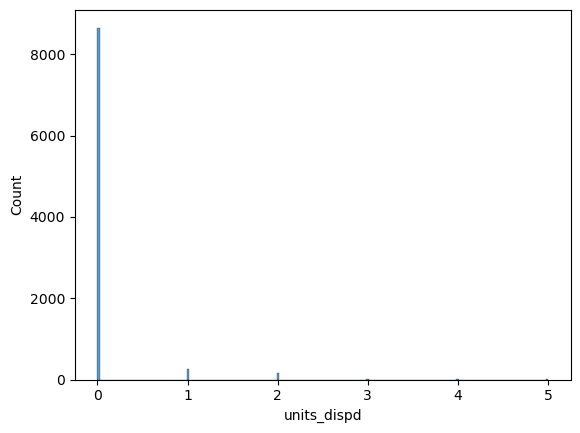

In [66]:
sns.histplot(data=nullprimeunit,x = 'units_dispd')

In [67]:
#I want to figure out how many rows have units_dispd > 0
nullprimeunit[nullprimeunit['units_dispd'] > 0]

,index,yr,agency,service,inci_id,calltime,case_id,callsource,nature,closecode,closed_as,secs_to_disp,secs_to_arrv,secs_to_close,disp,arrv,priority,primeunit,units_dispd,units_arrived,month,year
130,4085,2015,EPD,LAW,15010264,2015-01-14 09:39:39,NaN,PHONE,CHECK WELFARE,RSLV,RESOLVED,7354.0,7711.0,7981,1,1,5,NaN,1,0,1,2015
213,6452,2015,EPD,LAW,15015996,2015-01-21 16:03:08,NaN,PHONE,CHECK WELFARE,RSLV,RESOLVED,9341.0,9845.0,13761,1,1,4,NaN,3,2,1,2015
302,9330,2015,EPD,LAW,15022713,2015-01-29 22:24:00,NaN,PHONE,CHECK WELFARE,REL,REFERRED TO OTHER AGENCY,3398.0,NaN,11967,1,0,3,NaN,4,0,1,2015
320,9880,2015,EPD,LAW,15023902,2015-01-31 11:17:40,NaN,PHONE,CHECK WELFARE,DIS,DISREGARD,8479.0,8725.0,8904,1,1,7,NaN,1,1,1,2015
383,11266,2015,EPD,LAW,15027379,2015-02-04 18:41:42,NaN,PHONE,CHECK WELFARE,,NaN,1122.0,1360.0,6328,1,1,5,NaN,4,3,2,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92143,97887,2025,EPD,LAW,25271082,2025-10-23 21:05:40,NaN,PHONE,CHECK WELFARE,DDIS,DISREGARDED BY DISPATCH,341.0,NaN,44668,1,0,4,NaN,3,1,10,2025
92417,102747,2025,EPD,LAW,25285117,2025-11-08 17:00:11,NaN,W911,CHECK WELFARE,DIS,DISREGARD,4208.0,4208.0,4394,1,1,3,NaN,1,0,11,2025
92542,105374,2025,EPD,LAW,25292821,2025-11-18 12:20:04,NaN,PHONE,CHECK WELFARE,REL,REFERRED TO OTHER AGENCY,1024.0,NaN,1943,1,0,3,NaN,2,0,11,2025
92559,105691,2025,EPD,LAW,25293747,2025-11-19 13:44:54,NaN,PHONE,CHECK WELFARE,DIS,DISREGARD,527.0,NaN,709,1,0,3,NaN,2,0,11,2025


In [68]:
#So. The proportion of nature == 'WELFARE CHECK' calls
# that have no 'primeunit' and yet say that at least one was sent out is 
#0.00546. That's not very many. I'm going to drop these rows. 
#IMPORTANT: will need to put that as an assumption
419 / 76670

0.005464979783487674

Great. So. We've read in the Eugene CAD files for 2015-2025, filtered them for call nature of welfare check only, and combined them into a single df called WELFARE. We've also converted the calltime to a datetime object, and stripped out the whitespace and leading "_" from the primeunit column. Now we need to add an extra column that represents whether a call was answered by CAHOOTS, EPD, or if no unit was sent. In order to do this, I first need to drop every row where primeunit is nan and the # of units sent out is > 0. The resultant data frame should be 76251 rows long. Okay? Okay.

In [69]:
#dropping rows where the primeunit is a null value and more than 0 units were dispatched
welfare = WELFARE[(WELFARE['primeunit'].notna()) | (WELFARE['units_dispd'] == 0)]

In [70]:
#welfare
#this worked. It's 76251 rows :)

In [71]:
#Adding a column saying whether cahoots, epd, or neither answered the call

welfare["Institution"] = np.where(    
    welfare["primeunit"].str.contains("J|CAH", na=False),    
    "CAHOOTS",    
    np.where(        
        welfare["primeunit"].isna(),        
        "Neither",        
        "EPD"    
    )
)

/var/folders/0y/gklqyv_101130y1ly46wc5wm0000gn/T/ipykernel_3635/2384706366.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  welfare["Institution"] = np.where(


In [72]:
welfare

,index,yr,agency,service,inci_id,calltime,case_id,callsource,nature,closecode,closed_as,secs_to_disp,secs_to_arrv,secs_to_close,disp,arrv,priority,primeunit,units_dispd,units_arrived,month,year,Institution
0,2,2015,EPD,LAW,15000003,2015-01-01 00:01:05,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,708.0,1094.0,1538,1,1,5,3J79,1,1,1,2015,CAHOOTS
1,27,2015,EPD,LAW,15000052,2015-01-01 00:38:37,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,2402.0,2941.0,3594,1,1,5,3J79,1,1,1,2015,CAHOOTS
2,47,2015,EPD,LAW,15000092,2015-01-01 01:28:40,NaN,PHONE,CHECK WELFARE,UTL,UNABLE TO LOCATE,1305.0,1524.0,1824,1,1,5,5B44,1,1,1,2015,EPD
3,55,2015,EPD,LAW,15000107,2015-01-01 01:41:40,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,600.0,926.0,1285,1,1,5,3J79,1,1,1,2015,CAHOOTS
4,186,2015,EPD,LAW,15000435,2015-01-01 15:09:21,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,3018.0,3605.0,4369,1,1,7,3J79,1,1,1,2015,CAHOOTS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93210,117254,2025,EPD,LAW,25327100,2025-12-31 17:12:02,NaN,PHONE,CHECK WELFARE,DDIS,DISREGARDED BY DISPATCH,NaN,NaN,4147,0,0,4,NaN,0,0,12,2025,Neither
93211,117265,2025,EPD,LAW,25327137,2025-12-31 17:56:18,NaN,PHONE,CHECK WELFARE,UTL,UNABLE TO LOCATE,5655.0,6292.0,8294,1,1,3,4U72,2,2,12,2025,EPD
93212,117284,2025,EPD,LAW,25327208,2025-12-31 20:23:13,NaN,PHONE,CHECK WELFARE,WELC,WELFARE CHECK DONE,2828.0,3001.0,3451,1,1,3,5E56,2,2,12,2025,EPD
93213,117295,2025,EPD,LAW,25327228,2025-12-31 20:50:01,NaN,W911,CHECK WELFARE,DIS,DISREGARD,354.0,740.0,818,1,1,3,4U72,2,2,12,2025,EPD


In [73]:
welfare['service'].unique() #LAW is the only value, so can drop

array(['LAW ', 'OTHR'], dtype=object)

In [74]:
#dropping a few unneeded rows
welfare.drop(['index','agency','service','yr'],axis=1,inplace=True)

/var/folders/0y/gklqyv_101130y1ly46wc5wm0000gn/T/ipykernel_3635/200182458.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  welfare.drop(['index','agency','service','yr'],axis=1,inplace=True)


In [75]:
welfare.head()

,inci_id,calltime,case_id,callsource,nature,closecode,closed_as,secs_to_disp,secs_to_arrv,secs_to_close,disp,arrv,priority,primeunit,units_dispd,units_arrived,month,year,Institution
0,15000003,2015-01-01 00:01:05,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,708.0,1094.0,1538,1,1,5,3J79,1,1,1,2015,CAHOOTS
1,15000052,2015-01-01 00:38:37,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,2402.0,2941.0,3594,1,1,5,3J79,1,1,1,2015,CAHOOTS
2,15000092,2015-01-01 01:28:40,NaN,PHONE,CHECK WELFARE,UTL,UNABLE TO LOCATE,1305.0,1524.0,1824,1,1,5,5B44,1,1,1,2015,EPD
3,15000107,2015-01-01 01:41:40,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,600.0,926.0,1285,1,1,5,3J79,1,1,1,2015,CAHOOTS
4,15000435,2015-01-01 15:09:21,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,3018.0,3605.0,4369,1,1,7,3J79,1,1,1,2015,CAHOOTS


In [76]:
welfare['Institution'].unique()

array(['CAHOOTS', 'EPD', 'Neither'], dtype=object)

In [77]:
welfare.to_csv("./data/welfare.csv")

-- End of data cleaning --